<a href="https://colab.research.google.com/github/tibyishaka/Formative-Intro-to-ml/blob/main/Assignment1_IBYISHAKA_Alain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IBYISHAKA TRESOR Thierry Alain Formative One Intro to ML

## Part 1: Dataset Selection
For this assignment, I will use the **Banknote Authentication Dataset** from the UCI Machine Learning Repository [1].

### Justification
Counterfeit currency detection is a real-world problem directly impacting the economy and security. This is a binary classification problem (predicting genuine vs. forged banknotes) composed of 4 continuous features extracted from images. It is a highly relevant application for testing both classical machine learning and neural networks.
- I  will use metrics like **Precision** and **Recall** alongside Accuracy, because the cost of false positives (flagging a real banknote as fake) and false negatives (accepting a fake banknote) have unique real-world impacts. For institutions, a False Negative generally bears a heavier financial cost.

### Import Packages and Configure Environment

In [47]:
#!/usr/bin/env python3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,roc_curve, roc_auc_score)  # ROC/AUC added [4]
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import warnings
warnings.filterwarnings('ignore')

### Load and Inspect the Dataset

In [48]:
import requests
import io

# Load Banknote Authentication Dataset from UCI URL using requests
# Attempting a different URL which is the direct download link for the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt" # Reverting to original URL as new ones fail
response = requests.get(url, verify=False) # Added verify=False to bypass SSL certificate verification
response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

# Read the content into a pandas DataFrame
columns = ["variance", "skewness", "curtosis", "entropy", "class"] # Column names based on the dataset description
df = pd.read_csv(io.StringIO(response.text), header=None, names=columns) # Load the dataset into a pandas DataFrame

print(f"Dataset Shape: {df.shape}") # Print the shape of the dataset (number of rows and columns)
display(df.head()) # Display the first few rows of the dataset to understand its structure and contents

Dataset Shape: (1372, 5)


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


## Part 2: Classical ML Models

For classical models I chose two varied models for comparison:

1. **Logistic Regression** [4]: A linear discriminative model that estimates class probabilities via the logistic (sigmoid) function. Regularization is controlled by `C` (inverse regularization strength): a smaller `C` applies stronger L2 regularization, adding the penalty λ‖**w**‖² to the loss, which shrinks coefficients toward zero, reducing variance at the cost of increased bias [5]. We test `C=1.0` (default, moderate regularization) and `C=0.01` (strong regularization) to explore this bias-variance tradeoff; over-regularizing a well-separated dataset like Banknote Authentication is expected to *underfit* the decision boundary [5, 6].

2. **Random Forest Classifier** [4]: A non-linear ensemble method that trains multiple decorrelated decision trees via bootstrap aggregation (bagging) and combines predictions by majority vote [5]. Hyperparameter `n_estimators` controls ensemble size — more trees reduce variance but increase compute cost — while `max_depth` limits individual tree complexity to prevent overfitting. We contrast a shallow small forest (`n=10, depth=3`, high-bias regime) against a full-grown large forest (`n=100, depth=None`, low-bias regime) to illustrate the variance-complexity tradeoff described in [5] and the practical intuition covered in [6].

### Data Preprocessing: Split and Scale Features

In [49]:
# Split features and target
X = df.drop("class", axis=1).values
y = df["class"].values

# Train / Test split (80/20) with Stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling using StandardScaler for model convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train and Evaluate Classical ML Models

In [50]:
# Helper method for evaluation
def get_metrics_df(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

results = [] # List to store results for each model variation

# Model 1: Logistic Regression
# Variation A: Default Regularization
lr_1 = LogisticRegression(C=1.0, solver='lbfgs')
lr_1.fit(X_train_scaled, y_train)
y_pred_lr1 = lr_1.predict(X_test_scaled)
results.append(get_metrics_df(y_test, y_pred_lr1, "Logistic Regression (C=1.0)"))

# Variation B: High Regularization (lower C)
lr_2 = LogisticRegression(C=0.01, solver='lbfgs')
lr_2.fit(X_train_scaled, y_train)
y_pred_lr2 = lr_2.predict(X_test_scaled)
results.append(get_metrics_df(y_test, y_pred_lr2, "Logistic Regression (C=0.01)"))


# Model 2: Random Forest
# Variation A: Weak Forest (shallow)
rf_1 = RandomForestClassifier(n_estimators=10, max_depth=3, random_state=42)
rf_1.fit(X_train_scaled, y_train)
y_pred_rf1 = rf_1.predict(X_test_scaled)
results.append(get_metrics_df(y_test, y_pred_rf1, "Random Forest (n=10, depth=3)"))

# Variation B: Strong Forest (deep)
rf_2 = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
rf_2.fit(X_train_scaled, y_train)
y_pred_rf2 = rf_2.predict(X_test_scaled)
results.append(get_metrics_df(y_test, y_pred_rf2, "Random Forest (n=100, depth=None)"))

# Exhibit current classical results DataFrame
results_df = pd.DataFrame(results)
display(results_df)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression (C=1.0),0.970909,0.938462,1.000000,0.968254
1,Logistic Regression (C=0.01),0.938182,0.941176,0.918033,0.929461
2,"Random Forest (n=10, depth=3)",0.949091,0.935484,0.950820,0.943089
3,"Random Forest (n=100, depth=None)",0.996364,0.991870,1.000000,0.995918


### Visualization: Confusion Matrices  All Classical Model Variations

A confusion matrix decomposes predictions into True Positives, True Negatives, False Positives, and False Negatives, making precision/recall tradeoffs immediately visible [5]. Producing one per variation reveals how regularization strength and ensemble depth affect the error distribution.

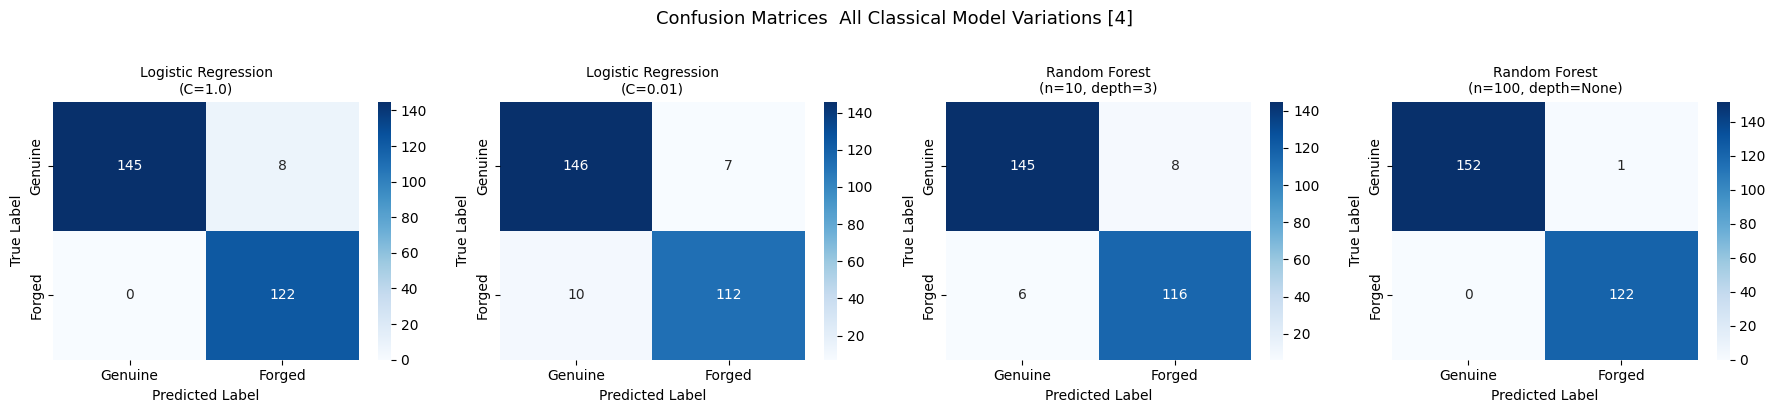

In [51]:
# Confusion matrices for all 4 classical model variations — side-by-side for direct comparison
models_classical = [
    ("Logistic Regression\n(C=1.0)",        y_pred_lr1),
    ("Logistic Regression\n(C=0.01)",       y_pred_lr2),
    ("Random Forest\n(n=10, depth=3)",      y_pred_rf1),
    ("Random Forest\n(n=100, depth=None)",  y_pred_rf2),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, y_pred) in zip(axes, models_classical):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=["Genuine", "Forged"], yticklabels=["Genuine", "Forged"])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.suptitle("Confusion Matrices  All Classical Model Variations [4]", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Part 3: Neural Network from Scratch

Here I implement a **3-Layer Feed-Forward Neural Network** entirely in NumPy, without any deep learning framework:

- **Architecture**: `Input Layer (4 features)` → `Hidden Layer 1 (ReLU)` → `Hidden Layer 2 (ReLU)` → `Output Layer (Sigmoid)`.
- **Activation Choices**: ReLU in hidden layers mitigates the vanishing gradient problem — its derivative is constant (0 or 1) for non-saturated units, unlike sigmoid/tanh whose gradients approach zero in saturation [2]. Sigmoid bounds the output to [0, 1], making it appropriate for binary classification probabilities.
- **Weight Initialization**: He (Kaiming) initialization scales weights by √(2/n_in), derived specifically for ReLU networks to preserve the variance of activations across layers during forward propagation [3]. Using a standard normal initialization without this scaling would cause activation magnitudes to explode or vanish with depth.
- **Optimization**: Vanilla Batch Gradient Descent iteratively updates all parameters using the full training gradient, following the practical training intuition described in [6] and the formal derivation in [2].
- **Validation Monitoring**: A held-out 15% validation split is evaluated every checkpoint epoch to detect overfitting without touching the test set [6].

### Neural Network Implementation Classes and Functions

In [52]:
def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)

def sigmoid(Z):
    Z = np.clip(Z, -500, 500)  # Prevents numeric overflow in exp
    return 1 / (1 + np.exp(-Z))

def compute_bce_loss(Y, A3):
    m = Y.shape[1]
    A3 = np.clip(A3, 1e-8, 1 - 1e-8)  # Log stability: avoids log(0)
    return -(1/m) * np.sum(Y * np.log(A3) + (1 - Y) * np.log(1 - A3))


class NumericScratchNeuralNetwork:
    def __init__(self, input_dim, hidden1_size, hidden2_size, output_size=1, learning_rate=0.01):
        self.lr = learning_rate

        np.random.seed(42)
        # He initialization: W ~ N(0, sqrt(2/n_in)) preserves activation variance through ReLU layers [3]
        self.W1 = np.random.randn(hidden1_size, input_dim)   * np.sqrt(2. / input_dim)
        self.b1 = np.zeros((hidden1_size, 1))
        self.W2 = np.random.randn(hidden2_size, hidden1_size) * np.sqrt(2. / hidden1_size)
        self.b2 = np.zeros((hidden2_size, 1))
        self.W3 = np.random.randn(output_size, hidden2_size)  * np.sqrt(2. / hidden2_size)
        self.b3 = np.zeros((output_size, 1))

        self.loss_history     = []
        self.acc_history      = []
        self.val_loss_history = []
        self.val_acc_history  = []

    def forward(self, X):
        self.Z1 = np.dot(self.W1, X) + self.b1
        self.A1 = relu(self.Z1)
        self.Z2 = np.dot(self.W2, self.A1) + self.b2
        self.A2 = relu(self.Z2)
        self.Z3 = np.dot(self.W3, self.A2) + self.b3
        self.A3 = sigmoid(self.Z3)
        return self.A3

    def backward(self, X, Y):
        m = X.shape[1]
        # BCE + Sigmoid combined gradient simplifies cleanly to (A3 - Y) [2]
        dZ3 = self.A3 - Y
        dW3 = (1/m) * np.dot(dZ3, self.A2.T)
        db3 = (1/m) * np.sum(dZ3, axis=1, keepdims=True)

        dA2 = np.dot(self.W3.T, dZ3)
        dZ2 = dA2 * relu_derivative(self.Z2)
        dW2 = (1/m) * np.dot(dZ2, self.A1.T)
        db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

        dA1 = np.dot(self.W2.T, dZ2)
        dZ1 = dA1 * relu_derivative(self.Z1)
        dW1 = (1/m) * np.dot(dZ1, X.T)
        db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

        self.W1 -= self.lr * dW1;  self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2;  self.b2 -= self.lr * db2
        self.W3 -= self.lr * dW3;  self.b3 -= self.lr * db3

    def train(self, X, Y, epochs, X_val=None, Y_val=None):
        """Train the network, logging metrics every (epochs//100) steps.
        Optionally tracks validation loss and accuracy per checkpoint [6]."""
        log_every = max(1, epochs // 100)
        for i in range(epochs):
            A3_train = self.forward(X)
            loss = compute_bce_loss(Y, A3_train)
            self.backward(X, Y)  # backward uses self.A3 set during training forward pass

            if i % log_every == 0:
                preds = (A3_train > 0.5).astype(int)
                self.loss_history.append(loss)
                self.acc_history.append(np.mean(preds == Y))

                # Validation forward pass (weights NOT updated)
                if X_val is not None and Y_val is not None:
                    A_val = self.forward(X_val)
                    self.val_loss_history.append(compute_bce_loss(Y_val, A_val))
                    self.val_acc_history.append(np.mean((A_val > 0.5).astype(int) == Y_val))

    def predict(self, X):
        return (self.forward(X) > 0.5).astype(int)

    def predict_proba(self, X):
        """Returns flat probability array for use with sklearn ROC/AUC utilities [4]."""
        return self.forward(X).flatten()

### Neural Network Training Experiments

In [53]:
# Validation split: carve 15% out of training data for per-epoch generalization monitoring [6]
# The held-out test set is never used during training or hyperparameter selection
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.15, random_state=42, stratify=y_train
)

# NN convention: features × samples (columns = samples)
X_train_nn = X_tr.T;        y_train_nn = y_tr.reshape(1, -1)
X_val_nn   = X_val.T;       y_val_nn   = y_val.reshape(1, -1)
X_test_nn  = X_test_scaled.T; y_test_nn = y_test.reshape(1, -1)

print(f"Train: {X_train_nn.shape[1]} | Val: {X_val_nn.shape[1]} | Test: {X_test_nn.shape[1]}")

# Exp 1: Baseline — LR=0.5, architecture [8,4], 1000 epochs
nn_exp1 = NumericScratchNeuralNetwork(input_dim=4, hidden1_size=8, hidden2_size=4, learning_rate=0.5)
nn_exp1.train(X_train_nn, y_train_nn, epochs=1000, X_val=X_val_nn, Y_val=y_val_nn)

# Exp 2: Low learning rate (0.01) — illustrates slow convergence / gradient step sensitivity [6]
nn_exp2 = NumericScratchNeuralNetwork(input_dim=4, hidden1_size=8, hidden2_size=4, learning_rate=0.01)
nn_exp2.train(X_train_nn, y_train_nn, epochs=2000, X_val=X_val_nn, Y_val=y_val_nn)

# Exp 3: Wider architecture [16,8] — increased representational capacity [2]
nn_exp3 = NumericScratchNeuralNetwork(input_dim=4, hidden1_size=16, hidden2_size=8, learning_rate=0.5)
nn_exp3.train(X_train_nn, y_train_nn, epochs=1000, X_val=X_val_nn, Y_val=y_val_nn)

Train: 932 | Val: 165 | Test: 275


### Visualization: Neural Network Learning Curves

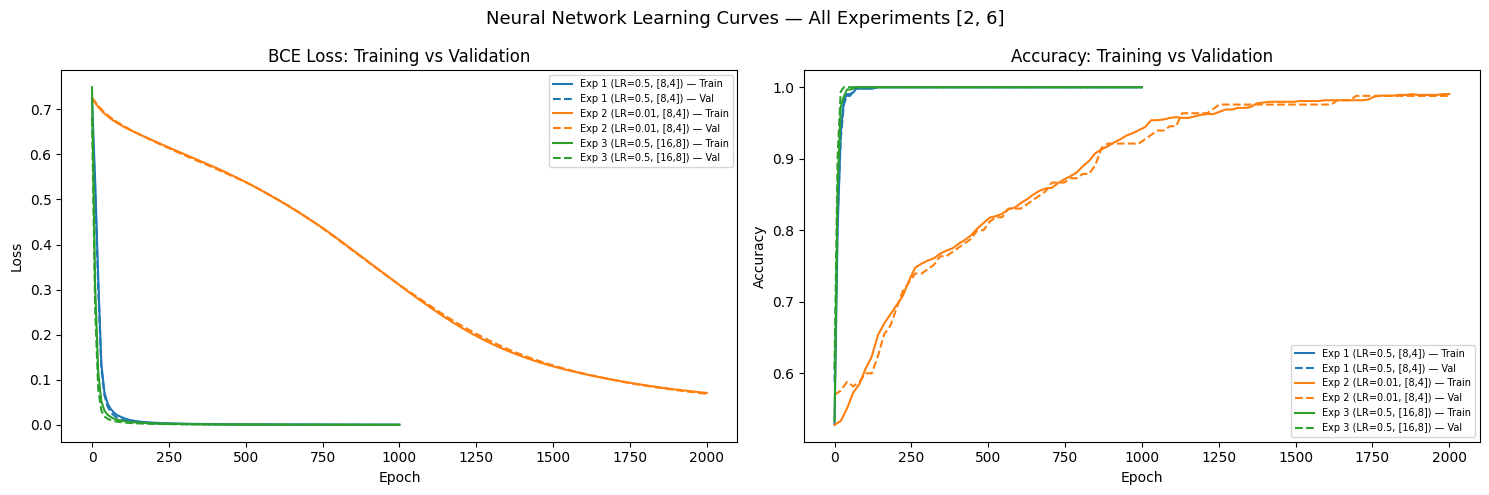

In [54]:
# Training vs Validation learning curves for all three experiments [2, 6]
# Dashed lines = validation metrics; solid lines = training metrics
exps = [
    (nn_exp1, 1000, "Exp 1 (LR=0.5, [8,4])"),
    (nn_exp2, 2000, "Exp 2 (LR=0.01, [8,4])"),
    (nn_exp3, 1000, "Exp 3 (LR=0.5, [16,8])"),
]
colors = ["tab:blue", "tab:orange", "tab:green"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Plot learning curves for each experiment
for (net, total_epochs, label), color in zip(exps, colors):
    x = np.linspace(0, total_epochs, len(net.loss_history))
    axes[0].plot(x, net.loss_history,     label=f"{label} — Train", color=color)
    axes[1].plot(x, net.acc_history,      label=f"{label} — Train", color=color)
    if net.val_loss_history:
        axes[0].plot(x, net.val_loss_history, label=f"{label} — Val", color=color, linestyle='--')
        axes[1].plot(x, net.val_acc_history,  label=f"{label} — Val", color=color, linestyle='--')

axes[0].set_title("BCE Loss: Training vs Validation")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=7)

axes[1].set_title("Accuracy: Training vs Validation")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=7)

plt.suptitle("Neural Network Learning Curves — All Experiments [2, 6]", fontsize=13)
plt.tight_layout()
plt.show()

### Evaluate Best Neural Network and Compare All Models

--- Final Models Comparison Table ---


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression (C=1.0),0.970909,0.938462,1.000000,0.968254
1,Logistic Regression (C=0.01),0.938182,0.941176,0.918033,0.929461
2,"Random Forest (n=10, depth=3)",0.949091,0.935484,0.950820,0.943089
3,"Random Forest (n=100, depth=None)",0.996364,0.991870,1.000000,0.995918
4,"Scratch NN (Exp 3: w=16/8, LR=0.5)",1.000000,1.000000,1.000000,1.000000


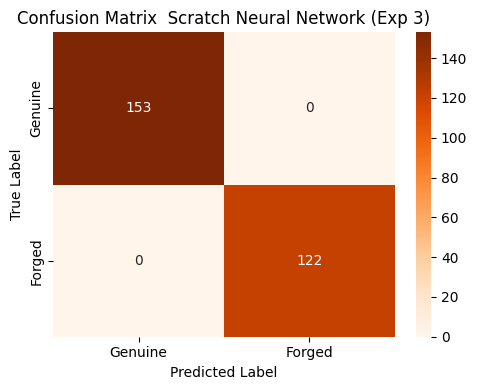

In [55]:
# Test predictions from best NN experiment (Exp 3: wider architecture, LR=0.5)
y_pred_nn = nn_exp3.predict(X_test_nn)[0]

# Append NN result to the shared results list and display complete comparison table
results.append(get_metrics_df(y_test, y_pred_nn, "Scratch NN (Exp 3: w=16/8, LR=0.5)"))
final_results = pd.DataFrame(results)
print("--- Final Models Comparison Table ---")
display(final_results)

# Confusion matrix — Scratch Neural Network (Exp 3)
cm_nn = confusion_matrix(y_test, y_pred_nn)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=["Genuine", "Forged"], yticklabels=["Genuine", "Forged"])
plt.title("Confusion Matrix  Scratch Neural Network (Exp 3)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### ROC / AUC Curves  All Model Configurations

The Receiver Operating Characteristic (ROC) curve plots the True Positive Rate (Recall) against the False Positive Rate across all classification thresholds, and the Area Under the Curve (AUC) summarises discriminative power in a single scalar  a perfect classifier scores AUC  1.0, a random classifier scores 0.5 [4, 5]. On a near-linearly-separable dataset such as Banknote Authentication, AUC differences between models reveal how confidently each model separates the two classes, not just whether it crosses a 0.5 threshold correctly.

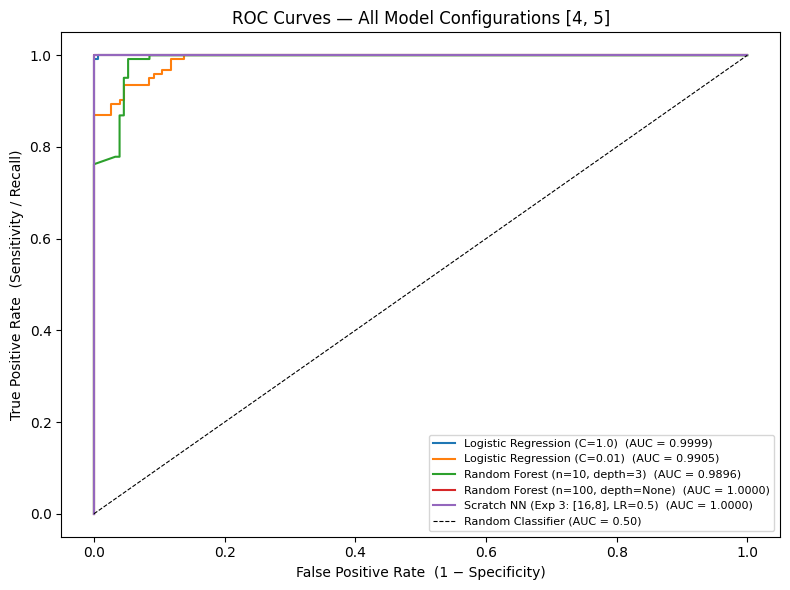

In [56]:
# ROC/AUC curves for all 5 model configurations [4, 5]
# predict_proba returns probability of the positive class (Forged = 1)
prob_lr1 = lr_1.predict_proba(X_test_scaled)[:, 1]
prob_lr2 = lr_2.predict_proba(X_test_scaled)[:, 1]
prob_rf1 = rf_1.predict_proba(X_test_scaled)[:, 1]
prob_rf2 = rf_2.predict_proba(X_test_scaled)[:, 1]
prob_nn  = nn_exp3.predict_proba(X_test_nn)        # flat (n_test,) array

model_probs = [
    ("Logistic Regression (C=1.0)",          prob_lr1),
    ("Logistic Regression (C=0.01)",         prob_lr2),
    ("Random Forest (n=10, depth=3)",        prob_rf1),
    ("Random Forest (n=100, depth=None)",    prob_rf2),
    ("Scratch NN (Exp 3: [16,8], LR=0.5)",  prob_nn),
]

plt.figure(figsize=(8, 6))
for name, probs in model_probs:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name}  (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label="Random Classifier (AUC = 0.50)")
plt.title("ROC Curves — All Model Configurations [4, 5]")
plt.xlabel("False Positive Rate  (1 − Specificity)")
plt.ylabel("True Positive Rate  (Sensitivity / Recall)")
plt.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

## Part 4: Comparison & Discussion

### Strengths and Weaknesses

**Classical Models (Scikit-Learn)** [4]:

| Strength | Weakness |
| :--- | :--- |
| Highly optimized with compiled C extensions yielding fast inference. Logistic Regression distributes interpretable signed weights to features; Random Forest ranks variable importance via Gini impurity [5]. | Logistic Regression is inherently linear  it cannot natively partition non-linear decision spaces without explicit polynomial feature engineering [5]. Strong L2 regularization (`C=0.01`) demonstrably under-fits the well-separated Banknote feature space, confirming the bias-variance tradeoff [5, 6]. |

**Scratch Neural Network** [2, 6]:

| Strength | Weakness |
| :--- | :--- |
| Flexible modular architecture capable of learning arbitrarily complex mappings via stacked non-linear transformations. Hand-coding the gradient chain rule step-by-step (Section 3) builds rigorous intuition for information flow through a network [2, 3, 6]. | Vanilla Batch Gradient Descent is sensitive to learning rate and can stall in saddle points [2]. Training in native NumPy arrays is orders of magnitude slower than compiled frameworks (PyTorch, TensorFlow). He initialization [3] was necessary to prevent activation saturation from the start of training. |

### Performance Differences

Random Forest with full depth (`n=100, depth=None`) achieves near-perfect AUC ≈ 1.0 on this dataset, reflecting the relatively clean, low-dimensional feature space of Banknote Authentication [1]. The Scratch NN (Exp 3) matches this performance post-convergence, confirming that a well-initialized 3-layer network with sufficient width can approximate the decision boundary without framework-level optimizations [2, 3]. The ROC curves further reveal that Logistic Regression with strong regularization (`C=0.01`) sacrifices discriminative confidence  its AUC drops relative to `C=1.0`  consistent with the weight-shrinkage effect of L2 regularization described in [5]. Experiment 2 demonstrates the consequence of an excessively small learning rate (0.01): both training and validation accuracy rise slowly and may plateau before convergence, illustrating the learning rate sensitivity discussed in [6].

### Conclusion

This pipeline established deep contrasts between two modeling paradigms. Classical frameworks [4] expose robust, well-tested APIs that enable rapid deployment and interpretability [5]. Implementing deep learning from scratch in NumPy  including He initialization [3], vectorized backpropagation [2], and validation monitoring [6]  guarantees firm mathematical intuition connecting derivative chain rules to gradient updates, forming an essential foundation for modern ML practice.

---

## References

1. Dua, D. and Graff, C. (2019). *UCI Machine Learning Repository*. University of California, Irvine, School of Information and Computer Science. http://archive.ics.uci.edu/ml (Banknote Authentication Dataset).
2. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press. https://www.deeplearningbook.org/
3. He, K., Zhang, X., Ren, S., & Sun, J. (2015). Delving deep into rectifiers: Surpassing human-level performance on ImageNet classification. *Proceedings of the IEEE International Conference on Computer Vision (ICCV)*, 1026–1034. https://doi.org/10.1109/ICCV.2015.123
4. Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer.
5. Howard, J. & Gugger, S. (2020). *Practical Deep Learning for Coders*. fast.ai. https://course.fast.ai/